# Computer Vision 1: Assignment 3

Task 2

Group Number 43

Marek Drwal

15.12.2025

## setup

In [94]:
import numpy as np
import skimage as ski
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor

## defs

In [95]:
def show_img(img, pth='', comment='', show=True):
    plt.imshow(img, cmap=plt.cm.gray)
    plt.title(comment +' ' + pth)
    if show:
        plt.show()

In [96]:
def load_display_img(pth, is_gray=False):
    img = ski.io.imread(pth)
    if not is_gray:
        show_img(img, pth, 'org')
        img = ski.color.rgb2gray(img)
    show_img(img, pth, 'gray')
    return img

In [97]:
def augment_img(img, pth='', display=True, noise_smooth=True):
    if noise_smooth:
        N = ski.util.random_noise(img, 'gaussian', var=0.01, rng=123)
        show_img(N, pth, 'noise')
        S = ski.filters.gaussian(N, sigma=1)
        show_img(S, pth, 'smooth')
        FN = ski.filters.sobel(N)
        show_img(FN, pth, 'Sobel on noise')
        FS = ski.filters.sobel(S)
        show_img(FS, pth, 'Sobel on smooth')
        return N, S, FN, FS
    FS = ski.filters.sobel(img)
    show_img(FS, pth, 'Sobel on')
    return FS

In [98]:
def plot_img_hist(img, no_bins=500):
    return plt.hist(img.ravel(), bins=no_bins, range=(0,1), histtype='step')

In [99]:
def binary_mask(img, threshold, pth='', name=''):
    masked_img = np.where(img.ravel() > threshold, True, False).reshape(img.shape)
    show_img(masked_img, pth, f'{name} masked with {threshold}')
    return masked_img

## imgs

In [100]:
pth = 'yellow_horizon.jpg'

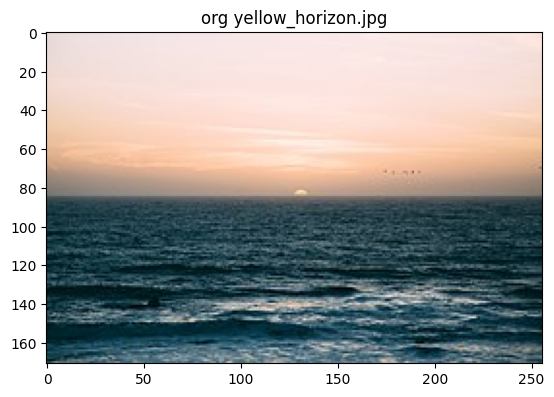

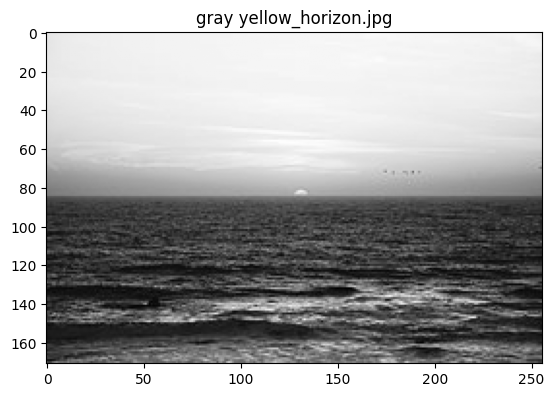

In [101]:
img = load_display_img(pth)

## Sobel

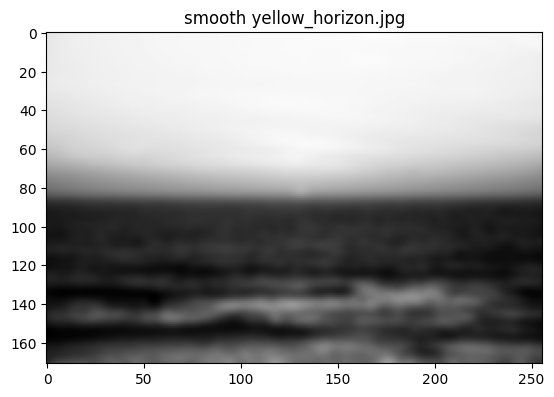

In [102]:
smooth_img = ski.filters.gaussian(img, 2.5, preserve_range=True)
show_img(smooth_img, pth, 'smooth')

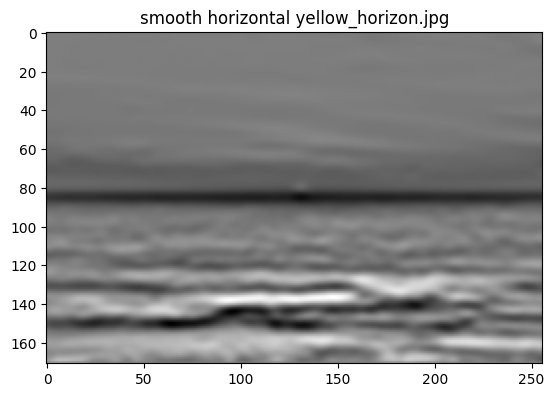

In [103]:
h_img = ski.filters.sobel_h(smooth_img)
show_img(h_img, pth, 'smooth horizontal')

## candidate pts

In [104]:
min_gradient_row_indices = np.argmin(h_img, axis=0)
min_gradient_row_indices.shape

(256,)

In [105]:
pts = np.zeros_like(img)
xs = []
ys = []

for x in range(0, img.shape[1]-1, img.shape[1] // 20): # horiz col
    y = min_gradient_row_indices[x]
    pts[y,x] = 1
    print(x, y, end=', ')
    xs.append(x)
    ys.append(y)

0 85, 12 85, 24 150, 36 85, 48 85, 60 150, 72 150, 84 149, 96 144, 108 85, 120 150, 132 85, 144 85, 156 85, 168 85, 180 85, 192 141, 204 85, 216 85, 228 85, 240 85, 252 85, 

In [106]:
len(ys)

22

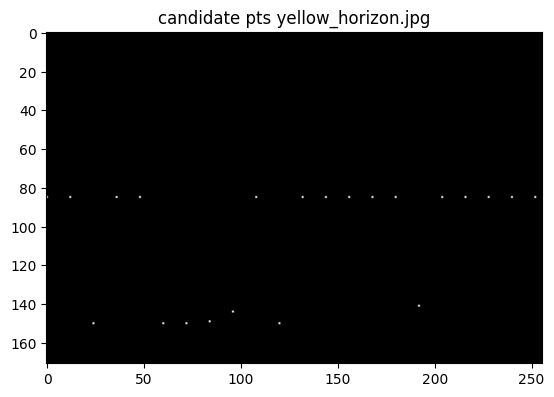

In [107]:
show_img(pts, pth, 'candidate pts')

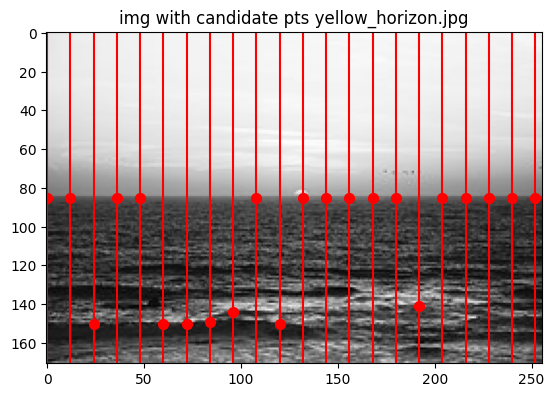

In [108]:
show_img(img, pth, 'img with candidate pts', False)
for x in xs:
    plt.axvline(x, ymax=img.shape[0], c='r')
plt.scatter(xs, ys, c='r', s=50)
plt.show()

## horizontal RANSAC

### fit

In [109]:
rr = RANSACRegressor()
rr

RANSACRegressor()

In [110]:
X = np.array(xs, ndmin=2).T
y = np.array(ys)

In [111]:
X.shape

(22, 1)

In [112]:
y.shape

(22,)

In [113]:
rr.fit(X, y)
rr

RANSACRegressor()

In [114]:
rr.get_params()

{'estimator': None,
 'is_data_valid': None,
 'is_model_valid': None,
 'loss': 'absolute_error',
 'max_skips': inf,
 'max_trials': 100,
 'min_samples': None,
 'random_state': None,
 'residual_threshold': None,
 'stop_n_inliers': inf,
 'stop_probability': 0.99,
 'stop_score': inf}

In [115]:
rr.estimator_

LinearRegression()

In [116]:
rr.estimator_.coef_

array([0.])

In [117]:
rr.estimator_.intercept_

np.float64(85.0)

In [118]:
rr.estimator_.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

### disp

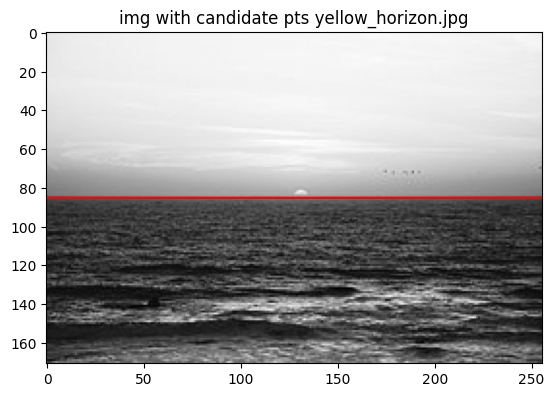

In [119]:
show_img(img, pth, 'img with candidate pts', False)
plt.axline(xy1=(0,rr.estimator_.intercept_), xy2=None, slope=rr.estimator_.coef_[0], c='r')
plt.show()

## rotation

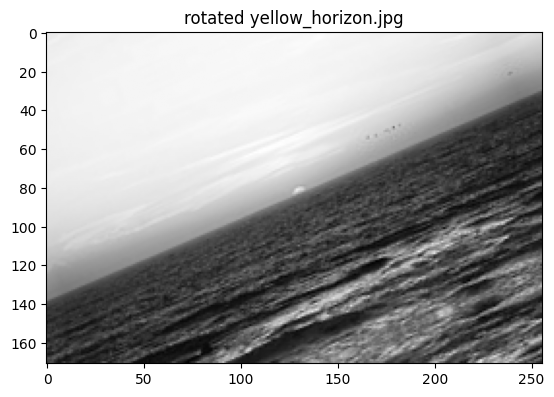

In [120]:
img = ski.transform.rotate(img, 23, mode='reflect')
show_img(img, pth, 'rotated')

## rotated Sobel

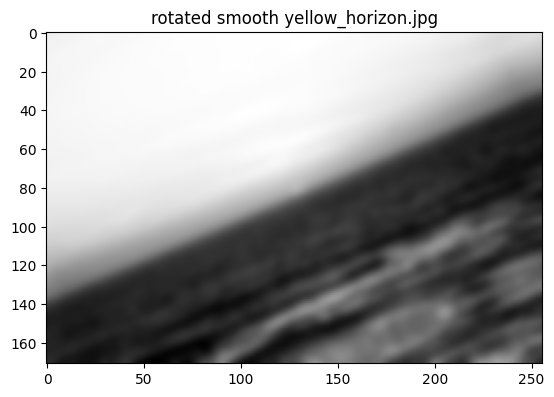

In [121]:
smooth_img = ski.filters.gaussian(img, 2.5, preserve_range=True)
show_img(smooth_img, pth, 'rotated smooth')

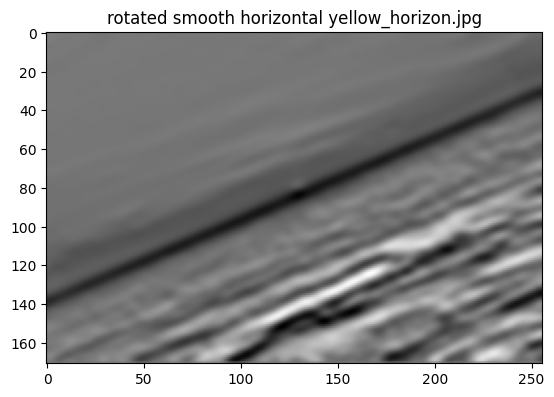

In [122]:
h_img = ski.filters.sobel_h(smooth_img)
show_img(h_img, pth, 'rotated smooth horizontal')

## rotated candidate pts

In [123]:
min_gradient_row_indices = np.argmin(h_img, axis=0)
min_gradient_row_indices.shape

(256,)

In [124]:
pts = np.zeros_like(img)
xs = []
ys = []

for x in range(0, img.shape[1]-1, img.shape[1] // 20): # horiz col
    y = min_gradient_row_indices[x]
    pts[y,x] = 1
    print(x, y, end=', ')
    xs.append(x)
    ys.append(y)

0 139, 12 134, 24 129, 36 124, 48 119, 60 114, 72 109, 84 104, 96 169, 108 163, 120 152, 132 83, 144 149, 156 145, 168 68, 180 167, 192 58, 204 113, 216 48, 228 43, 240 141, 252 136, 

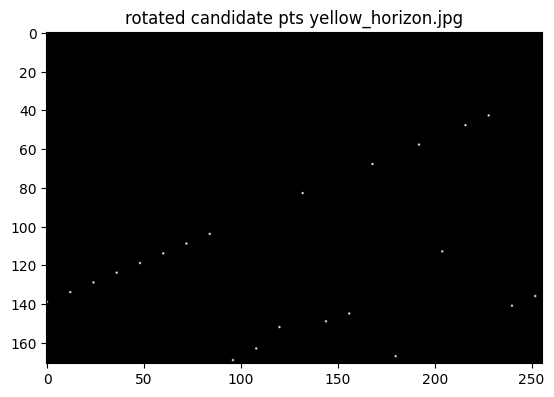

In [125]:
show_img(pts, pth, 'rotated candidate pts')

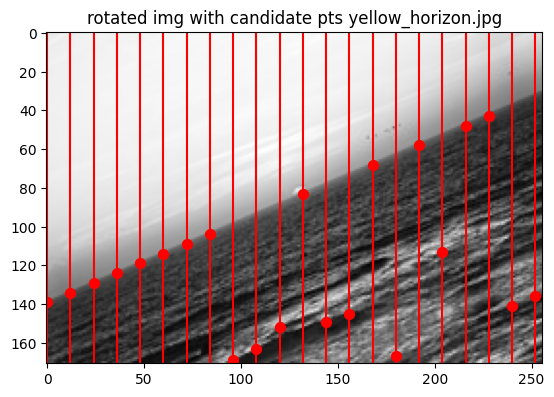

In [126]:
show_img(img, pth, 'rotated img with candidate pts', False)
for x in xs:
    plt.axvline(x, ymax=img.shape[0], c='r')
plt.scatter(xs, ys, c='r', s=50)
plt.show()

## rotated RANSAC

### fit

In [127]:
rr = RANSACRegressor()
rr

RANSACRegressor()

In [128]:
X = np.array(xs, ndmin=2).T
y = np.array(ys)

In [129]:
X.shape

(22, 1)

In [130]:
y.shape

(22,)

In [131]:
rr.fit(X, y)
rr

RANSACRegressor()

In [132]:
rr.get_params()

{'estimator': None,
 'is_data_valid': None,
 'is_model_valid': None,
 'loss': 'absolute_error',
 'max_skips': inf,
 'max_trials': 100,
 'min_samples': None,
 'random_state': None,
 'residual_threshold': None,
 'stop_n_inliers': inf,
 'stop_probability': 0.99,
 'stop_score': inf}

In [133]:
rr.estimator_

LinearRegression()

In [134]:
rr.estimator_.coef_

array([-0.42248006])

In [135]:
rr.estimator_.intercept_

np.float64(139.18420294032862)

In [136]:
rr.estimator_.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

### disp

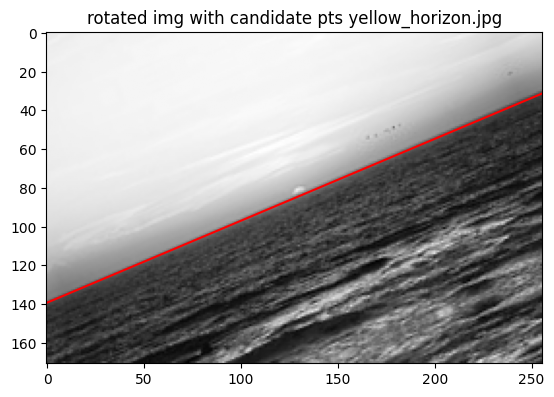

In [137]:
show_img(img, pth, 'rotated img with candidate pts', False)
plt.axline(xy1=(0,rr.estimator_.intercept_), xy2=None, slope=rr.estimator_.coef_[0], c='r')
plt.show()